# Лабораторная работа № 7
## Деревья решений и ансамбли на их основе

Цель работы:
1. Освоить принципы построения и настройки дерева решений с помощью sklearn.tree.DecisionTreeClassifier.
2. Познакомиться с базовыми ансамблевыми методами: бэггинг (Bagging) и бустинг (Boosting).
3. Сравнить эффективность одиночного дерева и ансамблей на практическом примере.

Используется набор данных **cancer_data.csv**. Признаки: Age, Gender, BMI, Smoking, GeneticRisk, PhysicalActivity, AlcoholIntake, CancerHistory. Целевая переменная **Diagnosis** — бинарная классификация (0 — отсутствие рака, 1 — наличие рака).

**Вариант 4 — прогнозирование рака.**

## 1. Импорт необходимых библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Matplotlib is building the font cache; this may take a moment.


## 2. Загрузка и первичный анализ данных

In [2]:
# Загружаем набор данных
df = pd.read_csv("cancer_data.csv")

# Отделяем признаки и целевую переменную
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

# Посмотрим на данные
print("Размерность признаков:", X.shape)
print("Названия признаков:", X.columns.tolist())
print("Размерность целевой переменной:", y.shape)
print("Уникальные классы:", y.unique())
print("\nПервые 5 строк признаков:")
print(X.head())

Размерность признаков: (1500, 8)
Названия признаков: ['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'AlcoholIntake', 'CancerHistory']
Размерность целевой переменной: (1500,)
Уникальные классы: [1 0]

Первые 5 строк признаков:
   Age  Gender        BMI  Smoking  GeneticRisk  PhysicalActivity  \
0   58       1  16.085313        0            1          8.146251   
1   71       0  30.828784        0            1          9.361630   
2   48       1  38.785084        0            2          5.135179   
3   34       0  30.040296        0            0          9.502792   
4   62       1  35.479721        0            0          5.356890   

   AlcoholIntake  CancerHistory  
0       4.148219              1  
1       3.519683              0  
2       4.728368              0  
3       2.044636              0  
4       3.309849              0  


In [3]:
# Полное представление о наборе данных
print("Размерность всего набора данных:", df.shape)
print("\nПервые 5 строк:")
display(df.head())
print("\nИнформация о столбцах:")
df.info()
print("\nОписательная статистика:")
display(df.describe())
print("\nПропуски по столбцам:")
print(df.isna().sum())
print("\nКоличество дубликатов:", df.duplicated().sum())
print("\nРаспределение классов Diagnosis:")
print(y.value_counts().sort_index())

Размерность всего набора данных: (1500, 9)

Первые 5 строк:


,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1



Информация о столбцах:
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB

Описательная статистика:


,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,50.320000,0.490667,27.513321,0.269333,0.508667,4.897929,2.417987,0.144000,0.371333
std,17.640968,0.500080,7.230012,0.443761,0.678895,2.866162,1.419318,0.351207,0.483322
min,20.000000,0.000000,15.000291,0.000000,0.000000,0.002410,0.001215,0.000000,0.000000
25%,35.000000,0.000000,21.483134,0.000000,0.000000,2.434609,1.210598,0.000000,0.000000
50%,51.000000,0.000000,27.598494,0.000000,0.000000,4.834316,2.382971,0.000000,0.000000
75%,66.000000,1.000000,33.850837,1.000000,1.000000,7.409896,3.585624,0.000000,1.000000
max,80.000000,1.000000,39.958688,1.000000,2.000000,9.994607,4.987115,1.000000,1.000000



Пропуски по столбцам:
Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64

Количество дубликатов: 0

Распределение классов Diagnosis:
Diagnosis
0    943
1    557
Name: count, dtype: int64


### Вывод по первичному анализу

Набор содержит 1500 записей, 8 признаков и целевую переменную Diagnosis. Пропусков и полностью совпадающих строк нет, поэтому заполнение пропусков и удаление дубликатов не требуются. Все признаки уже представлены числами. Класс 0 содержит 943 записи, класс 1 — 557 записей; классы представлены неравномерно.

## 3. Разделение данных на обучающую и тестовую выборки

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (1200, 8)
Размер тестовой выборки: (300, 8)


### 3.1. Предобработка данных

Признаки Gender, Smoking и CancerHistory уже имеют бинарную кодировку 0/1, а GeneticRisk — порядковую кодировку 0/1/2. Используем **OrdinalEncoder**, сохраняя эти значения, чтобы выполнить пункт задания о кодировании средствами sklearn.

Количественные признаки Age, BMI, PhysicalActivity и AlcoholIntake нормализуем с помощью **MinMaxScaler**. Значения обучающей выборки приводятся к диапазону от 0 до 1. Значения тестовой выборки могут выходить за этот диапазон, если выходят за границы обучающей.

Для деревьев решений нормализация обычно не требуется, но выполняется согласно заданию. В каждой модели объединяем предобработку и классификатор в **Pipeline**. Поэтому при кросс-валидации кодировщик и нормализатор обучаются только на тренировочной части каждого фолда. Целевой столбец Diagnosis в предобработку признаков не включается.

In [5]:
# Категориальные и количественные признаки
categorical_features = ["Gender", "Smoking", "GeneticRisk", "CancerHistory"]
numerical_features = ["Age", "BMI", "PhysicalActivity", "AlcoholIntake"]

# Сохраняем исходный порядок категорий: 0/1 и 0/1/2
preprocessor = ColumnTransformer(
    transformers=[
        ("categories", OrdinalEncoder(categories=[[0, 1], [0, 1], [0, 1, 2], [0, 1]]), categorical_features),
        ("normalization", MinMaxScaler(), numerical_features)
    ],
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [6]:
# Посмотрим на результат предобработки обучающей выборки
# Этот преобразователь используется для просмотра; модели обучают свои копии в Pipeline
preview_preprocessor = clone(preprocessor)
X_train_prepared = preview_preprocessor.fit_transform(X_train)
feature_names = X_train_prepared.columns.tolist()
print("Первые 5 строк после кодирования и нормализации:")
display(X_train_prepared.head())

Первые 5 строк после кодирования и нормализации:


,Gender,Smoking,GeneticRisk,CancerHistory,Age,BMI,PhysicalActivity,AlcoholIntake
1376,0.0,0.0,0.0,0.0,0.416667,0.371548,0.469303,0.157702
787,1.0,0.0,2.0,0.0,0.683333,0.384467,0.156410,0.463521
1162,1.0,0.0,0.0,1.0,0.800000,0.774419,0.456432,0.808006
1287,0.0,0.0,0.0,0.0,0.233333,0.921052,0.233999,0.041755
1041,1.0,0.0,1.0,0.0,0.783333,0.715131,0.085620,0.672400


## 4. Построение и оценка базового дерева решений

In [7]:
# Создаем и обучаем дерево решений вместе с предобработкой
base_dt = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("model", DecisionTreeClassifier(random_state=42))
])
base_dt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Age','Gender','BMI',...,'PhysicalActivity','AlcoholIntake', 'CancerHistory']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categories', ...), ('normalization', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is e

In [8]:
# Делаем прогнозы
y_pred_base = base_dt.predict(X_test)

# Оцениваем точность
accuracy_base = accuracy_score(y_test, y_pred_base)
print(f"Точность базового дерева на тесте: {accuracy_base:.4f}")

Точность базового дерева на тесте: 0.8567


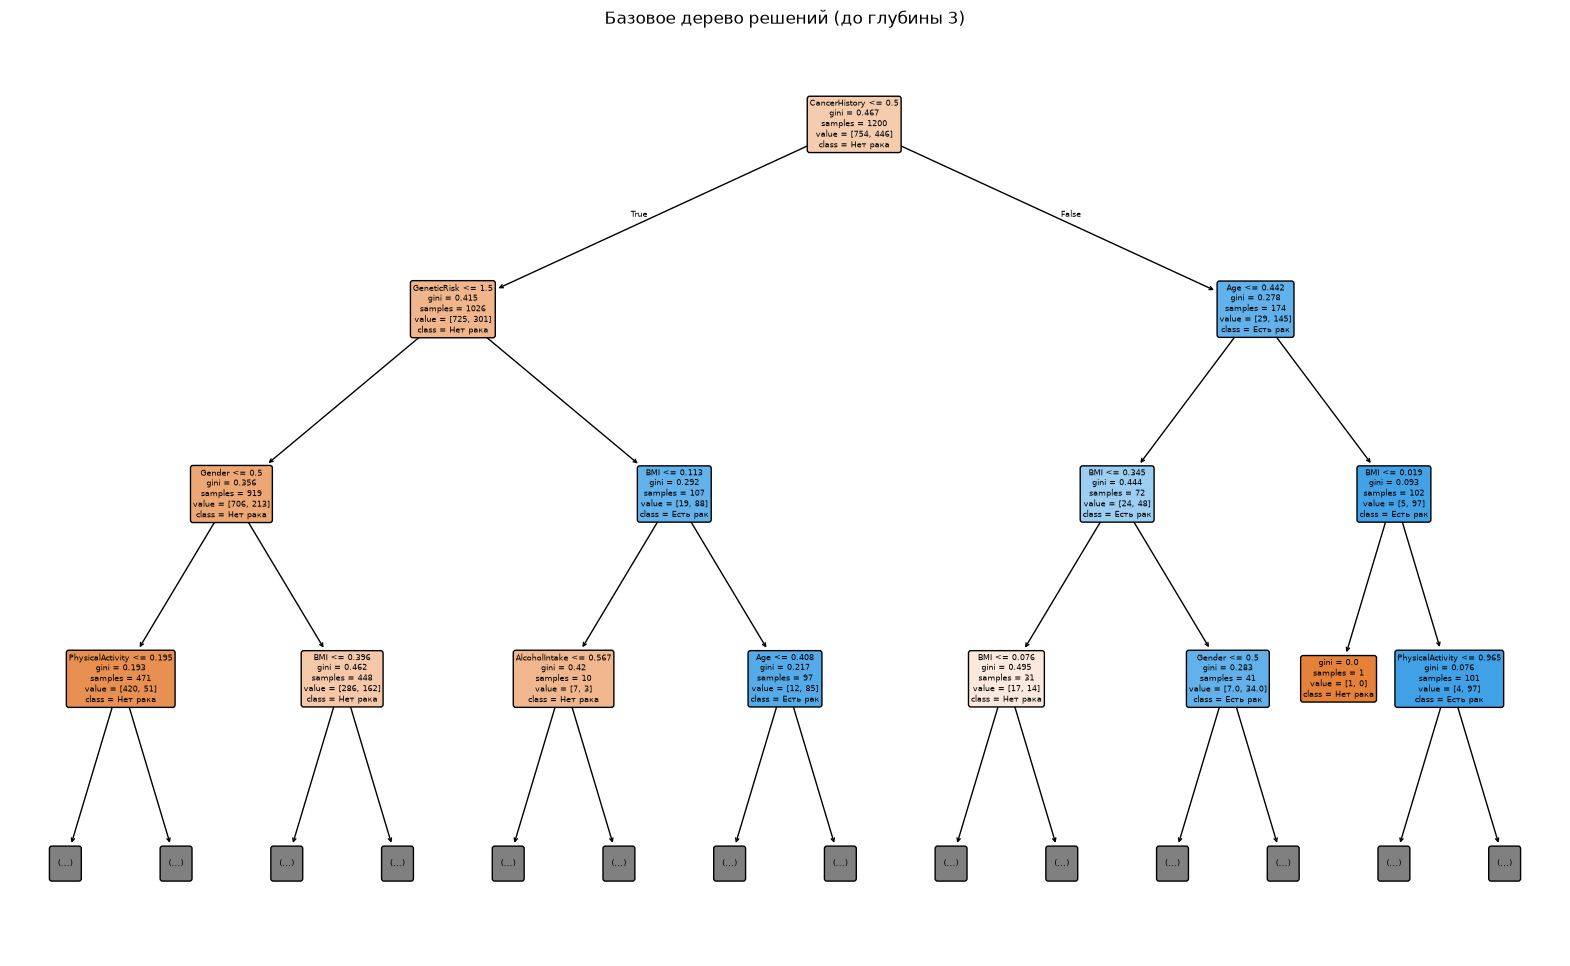

In [9]:
# Визуализируем первые уровни базового дерева
plt.figure(figsize=(20, 12))
plot_tree(base_dt.named_steps["model"], filled=True, feature_names=feature_names,
          class_names=["Нет рака", "Есть рак"], rounded=True, max_depth=3)
# max_depth ограничивает только изображение, а не обученную модель
plt.title("Базовое дерево решений (до глубины 3)")
plt.show()

На схемах дерева пороги количественных признаков показаны после нормализации. Кодировка категориальных признаков сохранена.

## 5. Борьба с переобучением: настройка гиперпараметров

In [10]:
# Попробуем ограничить глубину дерева
tuned_dt = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("model", DecisionTreeClassifier(max_depth=3, random_state=42))
])
tuned_dt.fit(X_train, y_train)

y_pred_tuned = tuned_dt.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Точность настроенного дерева (max_depth=3) на тесте: {accuracy_tuned:.4f}")

Точность настроенного дерева (max_depth=3) на тесте: 0.8000


In [11]:
# Кросс-валидация только на обучающей выборке
# Предобработка обучается заново внутри каждого фолда
cv_scores_base = cross_val_score(base_dt, X_train, y_train, cv=5, scoring="accuracy")
cv_scores_tuned = cross_val_score(tuned_dt, X_train, y_train, cv=5, scoring="accuracy")

print(f"Кросс-валидация, базовое дерево: {np.mean(cv_scores_base):.4f} (+/- {np.std(cv_scores_base) * 2:.4f})")
print(f"Кросс-валидация, настроенное дерево: {np.mean(cv_scores_tuned):.4f} (+/- {np.std(cv_scores_tuned) * 2:.4f})")

Кросс-валидация, базовое дерево: 0.8283 (+/- 0.0735)
Кросс-валидация, настроенное дерево: 0.7742 (+/- 0.0493)


### Вывод по настройке дерева

Базовое дерево получило точность **85.67%**, а дерево с глубиной 3 — **80.00%** на тестовой выборке. Точность ограниченного дерева на обучении составляет **78.92%**. Таким образом, глубина 3 слишком мала для этого набора данных и приводит к недообучению. Ограничение глубины не всегда улучшает качество.

Средняя accuracy на пяти фолдах обучающей выборки составляет 0.8283 для базового дерева и 0.7742 для дерева с глубиной 3. Выведенное значение «+/-» — два стандартных отклонения результатов по фолдам, а не рассчитанный доверительный интервал.

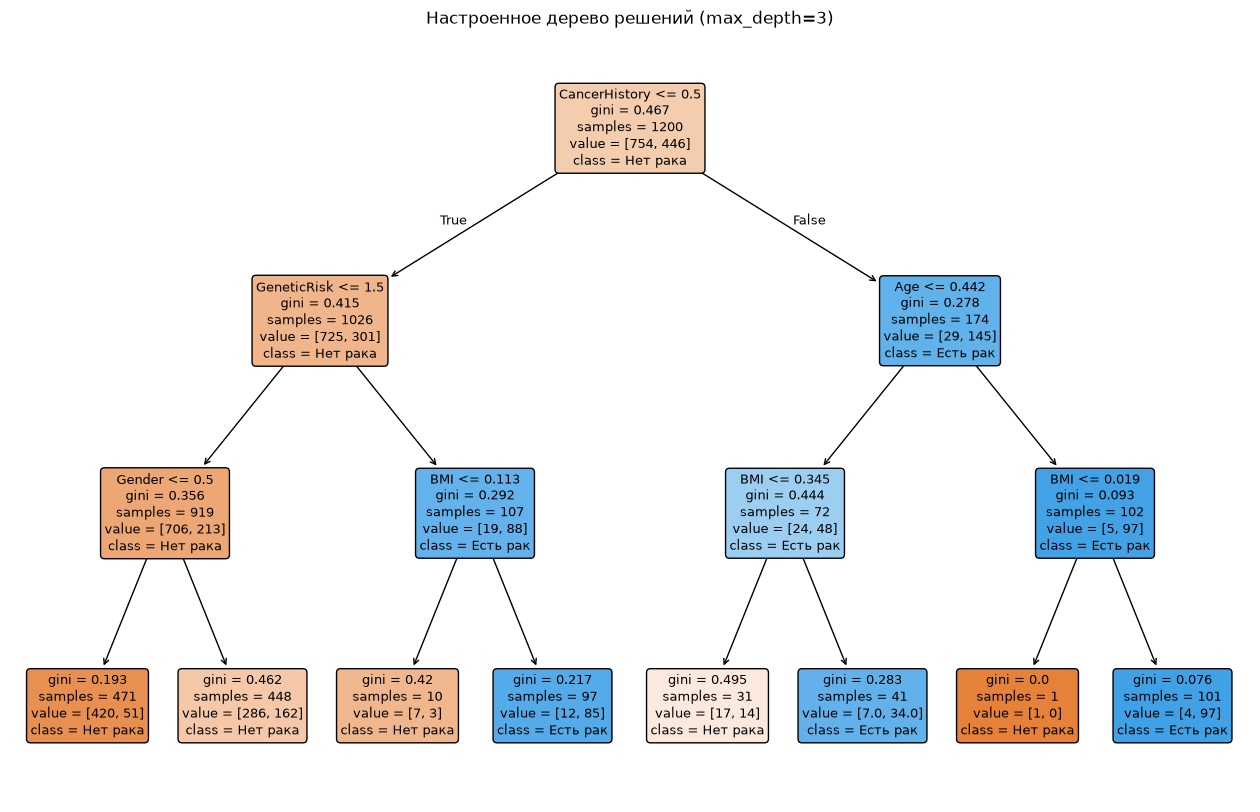

In [12]:
# Визуализируем настроенное дерево
plt.figure(figsize=(16, 10))
plot_tree(tuned_dt.named_steps["model"], filled=True, feature_names=feature_names,
          class_names=["Нет рака", "Есть рак"], rounded=True)
plt.title("Настроенное дерево решений (max_depth=3)")
plt.show()

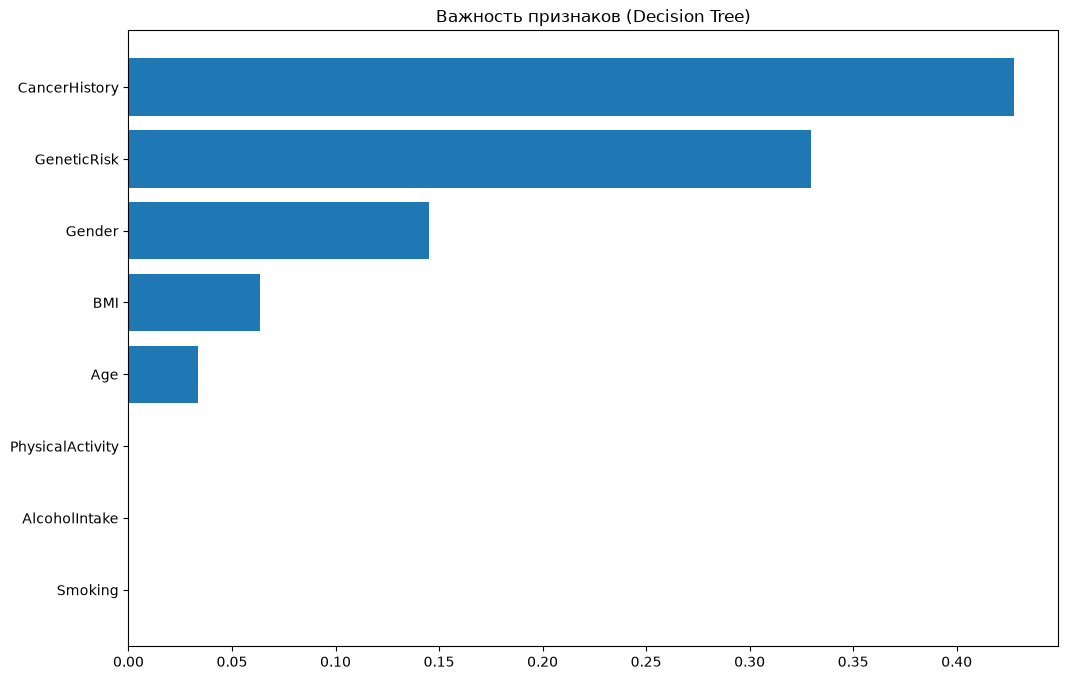

In [13]:
# Важность признаков
importances = tuned_dt.named_steps["model"].feature_importances_
indices = np.argsort(importances)[::-1]
top_n = min(10, len(feature_names))  # признаков может быть меньше 10
plt.figure(figsize=(12, 8))
plt.title("Важность признаков (Decision Tree)")
plt.barh(range(top_n), importances[indices][:top_n])  # Показываем все доступные признаки
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]])
plt.gca().invert_yaxis()
plt.show()

## 6. Ансамбли: Случайный лес (Бэггинг)

In [14]:
# Создаем и обучаем случайный лес из 100 деревьев
rf = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])
rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Age','Gender','BMI',...,'PhysicalActivity','AlcoholIntake', 'CancerHistory']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categories', ...), ('normalization', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is e

In [15]:
# Прогноз и оценка
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Точность Случайного леса на тесте: {accuracy_rf:.4f}")

Точность Случайного леса на тесте: 0.9500


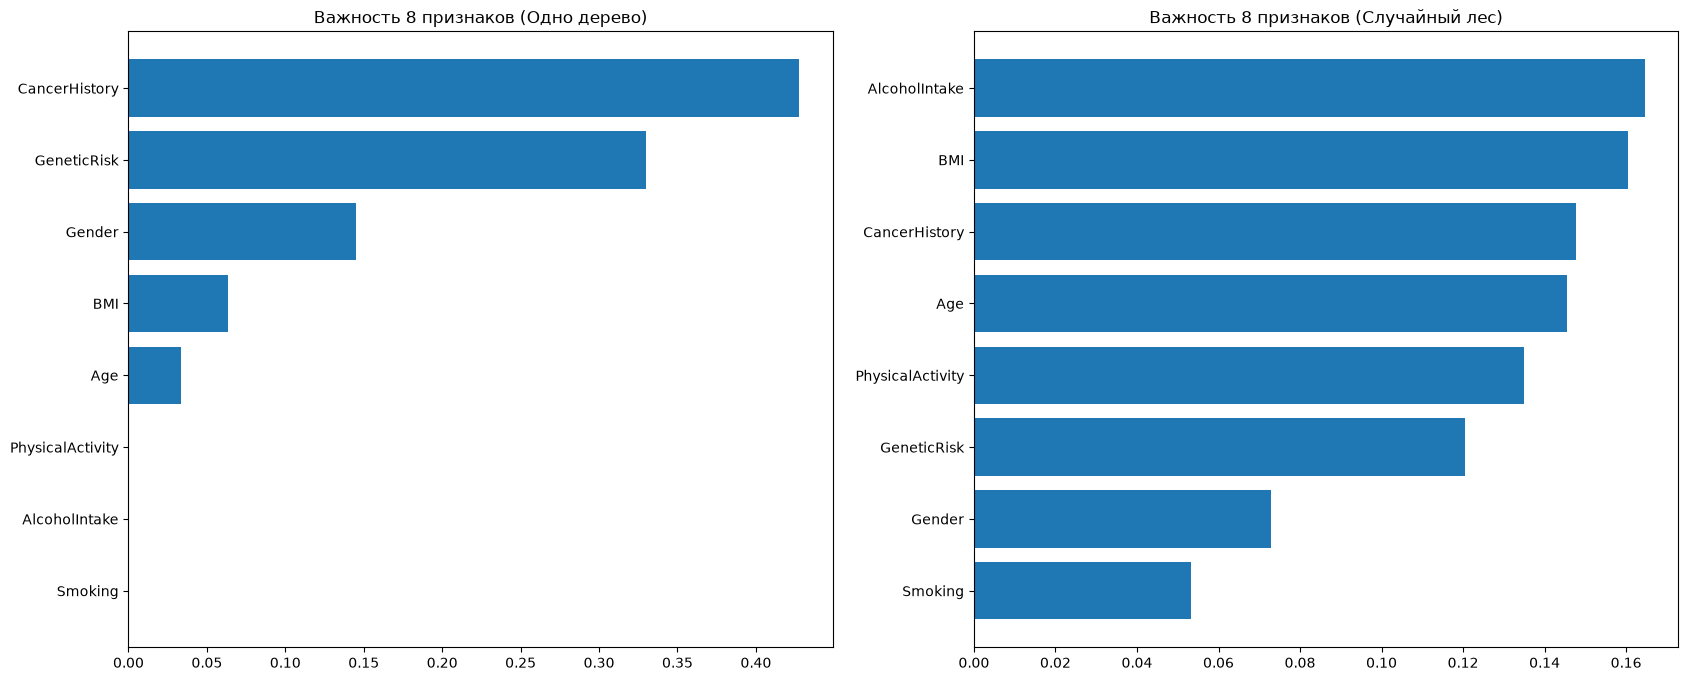

In [16]:
# Сравним важность признаков с одиночным деревом
rf_importances = rf.named_steps["model"].feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
ax1.barh(range(top_n), importances[indices][:top_n])
ax1.set_title(f"Важность {top_n} признаков (Одно дерево)")
ax1.set_yticks(range(top_n))
ax1.set_yticklabels([feature_names[i] for i in indices[:top_n]])
ax1.invert_yaxis()

ax2.barh(range(top_n), rf_importances[indices_rf][:top_n])
ax2.set_title(f"Важность {top_n} признаков (Случайный лес)")
ax2.set_yticks(range(top_n))
ax2.set_yticklabels([feature_names[i] for i in indices_rf[:top_n]])
ax2.invert_yaxis()
plt.show()

## 7. Ансамбли: Градиентный бустинг (Boosting)

In [17]:
# Создаем и обучаем Gradient Boosting
gb = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("model", GradientBoostingClassifier(n_estimators=100, random_state=42))
])
gb.fit(X_train, y_train)

# Прогноз и оценка
y_pred_gb = gb.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Точность Gradient Boosting на тесте: {accuracy_gb:.4f}")

Точность Gradient Boosting на тесте: 0.9467


## 8. Сравнение всех моделей

In [18]:
# Создаем сводную таблицу результатов уже обученных моделей
models = {
    'Base Decision Tree': base_dt,
    'Tuned Decision Tree': tuned_dt,
    'Random Forest': rf,
    'Gradient Boosting': gb
}

results = {}
for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = {'Train Accuracy': train_acc, 'Test Accuracy': test_acc}

                     Train Accuracy  Test Accuracy
Base Decision Tree         1.000000       0.856667
Tuned Decision Tree        0.789167       0.800000
Random Forest              1.000000       0.950000
Gradient Boosting          0.967500       0.946667


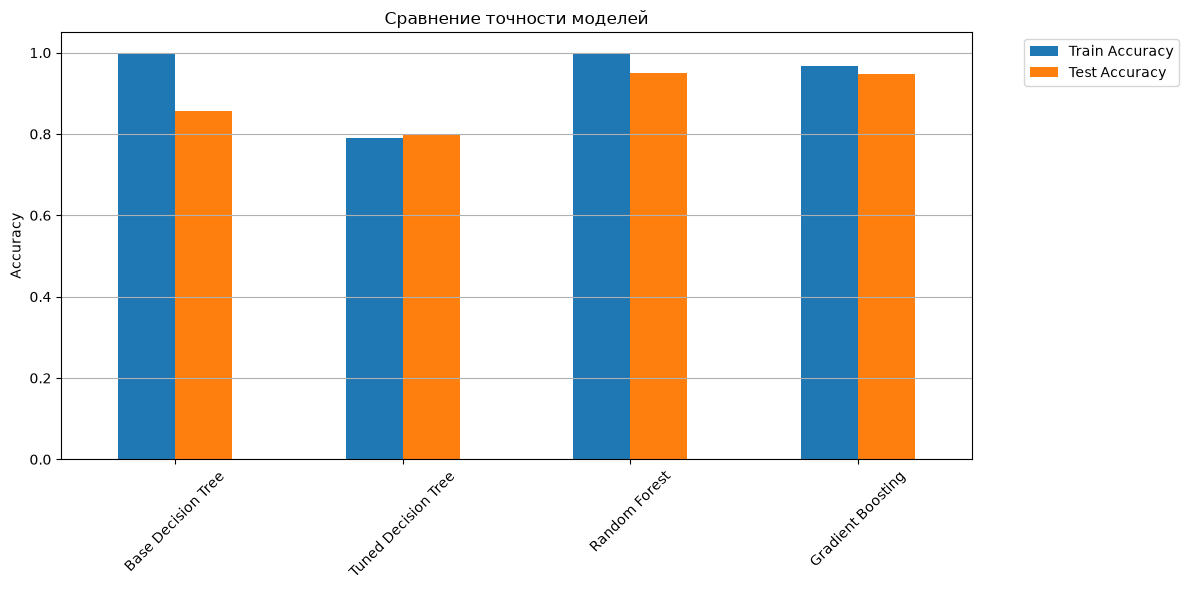

In [19]:
# Выводим результаты в виде DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

# Строим bar-plot для наглядности
results_df[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(12, 6))
plt.title("Сравнение точности моделей")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Вывод по сравнению моделей

На общей тестовой выборке первой части точность составила:

- базовое дерево — 85.67%;
- дерево с глубиной 3 — 80.00%;
- Random Forest — 95.00%;
- Gradient Boosting — 94.67%.

Наибольшую тестовую accuracy в этом сравнении показал **Random Forest**. У базового дерева и случайного леса тренировочная точность существенно выше тестовой, что показывает разрыв между качеством на обучении и на новых данных. Для дерева глубины 3 низкая точность и на обучении, и на тесте указывает на недостаточную сложность модели.

# Случайный лес (Random Forest)

Цель работы:
1. Освоить метод Random Forest (Случайный лес) — алгоритм машинного обучения, относящийся к классу ансамблевых методов.
2. Создать и обучить модель Random Forest.
3. Оценить эффективность алгоритма на практическом примере.
4. Подобрать гиперпараметры для улучшения модели.

Используется тот же набор данных **cancer_data.csv** (бинарная классификация по Diagnosis).

В этой части используется разделение 70/30, как во втором примере. Результаты двух частей получены на разных тестовых выборках, поэтому их точности напрямую не сравниваются.

## 1. Импорт необходимых библиотек

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Для воспроизводимости результатов
np.random.seed(42)

## 2. Загрузка и первичный анализ данных

In [21]:
# Загружаем набор данных
df = pd.read_csv("cancer_data.csv")

X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

# Посмотрим на данные
print("Размерность признаков:", X.shape)
print("Названия признаков:", X.columns.tolist())
print("Размерность целевой переменной:", y.shape)
print("Уникальные классы:", y.unique())
print("\nПервые 5 строк признаков:")
print(X.head())

Размерность признаков: (1500, 8)
Названия признаков: ['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'AlcoholIntake', 'CancerHistory']
Размерность целевой переменной: (1500,)
Уникальные классы: [1 0]

Первые 5 строк признаков:
   Age  Gender        BMI  Smoking  GeneticRisk  PhysicalActivity  \
0   58       1  16.085313        0            1          8.146251   
1   71       0  30.828784        0            1          9.361630   
2   48       1  38.785084        0            2          5.135179   
3   34       0  30.040296        0            0          9.502792   
4   62       1  35.479721        0            0          5.356890   

   AlcoholIntake  CancerHistory  
0       4.148219              1  
1       3.519683              0  
2       4.728368              0  
3       2.044636              0  
4       3.309849              0  


In [22]:
# Краткая проверка структуры и состояния данных
print("Размерность всего набора данных:", df.shape)
df.info()
display(df.describe())
print("\nКоличество пропусков:", df.isna().sum().sum())
print("Количество дубликатов:", df.duplicated().sum())
print("\nРаспределение классов:")
print(y.value_counts().sort_index())

Размерность всего набора данных: (1500, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB


,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,50.320000,0.490667,27.513321,0.269333,0.508667,4.897929,2.417987,0.144000,0.371333
std,17.640968,0.500080,7.230012,0.443761,0.678895,2.866162,1.419318,0.351207,0.483322
min,20.000000,0.000000,15.000291,0.000000,0.000000,0.002410,0.001215,0.000000,0.000000
25%,35.000000,0.000000,21.483134,0.000000,0.000000,2.434609,1.210598,0.000000,0.000000
50%,51.000000,0.000000,27.598494,0.000000,0.000000,4.834316,2.382971,0.000000,0.000000
75%,66.000000,1.000000,33.850837,1.000000,1.000000,7.409896,3.585624,0.000000,1.000000
max,80.000000,1.000000,39.958688,1.000000,2.000000,9.994607,4.987115,1.000000,1.000000



Количество пропусков: 0
Количество дубликатов: 0

Распределение классов:
Diagnosis
0    943
1    557
Name: count, dtype: int64


## 3. Разделение данных на обучающую и тестовую выборки

In [23]:
# Разделяем данные на обучающую и тестовую выборки (70/30), как во втором примере
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Обучающая выборка: {X_train_rf.shape[0]} samples")
print(f"Тестовая выборка: {X_test_rf.shape[0]} samples")

Обучающая выборка: 1050 samples
Тестовая выборка: 450 samples


### 3.1. Предобработка данных

Признаки Gender, Smoking и CancerHistory уже имеют бинарную кодировку 0/1, а GeneticRisk — порядковую кодировку 0/1/2. Используем **OrdinalEncoder**, сохраняя эти значения, чтобы выполнить пункт задания о кодировании средствами sklearn.

Количественные признаки Age, BMI, PhysicalActivity и AlcoholIntake нормализуем с помощью **MinMaxScaler**. Значения обучающей выборки приводятся к диапазону от 0 до 1. Значения тестовой выборки могут выходить за этот диапазон, если выходят за границы обучающей.

Для деревьев решений нормализация обычно не требуется, но выполняется согласно заданию. В каждой модели объединяем предобработку и классификатор в **Pipeline**. Поэтому при кросс-валидации кодировщик и нормализатор обучаются только на тренировочной части каждого фолда. Целевой столбец Diagnosis в предобработку признаков не включается.

In [24]:
# Категориальные и количественные признаки
categorical_features = ["Gender", "Smoking", "GeneticRisk", "CancerHistory"]
numerical_features = ["Age", "BMI", "PhysicalActivity", "AlcoholIntake"]

# Сохраняем исходный порядок категорий: 0/1 и 0/1/2
preprocessor = ColumnTransformer(
    transformers=[
        ("categories", OrdinalEncoder(categories=[[0, 1], [0, 1], [0, 1, 2], [0, 1]]), categorical_features),
        ("normalization", MinMaxScaler(), numerical_features)
    ],
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [25]:
# Проверим результат кодирования и нормализации
preview_preprocessor_rf = clone(preprocessor)
X_train_prepared_rf = preview_preprocessor_rf.fit_transform(X_train_rf)
feature_names_rf = X_train_prepared_rf.columns.tolist()
display(X_train_prepared_rf.head())

,Gender,Smoking,GeneticRisk,CancerHistory,Age,BMI,PhysicalActivity,AlcoholIntake
485,1.0,0.0,1.0,0.0,0.433333,0.973614,0.008864,0.109345
527,0.0,0.0,0.0,0.0,0.350000,0.872018,0.707114,0.250422
199,1.0,0.0,0.0,0.0,0.700000,0.260235,0.797802,0.743492
889,0.0,0.0,1.0,0.0,0.566667,0.340943,0.766661,0.021953
844,0.0,0.0,1.0,0.0,0.433333,0.431235,0.930490,0.961705


## 4. Создание и обучение модели Random Forest

In [26]:
# Создаем модель Random Forest вместе с предобработкой
# n_estimators - количество деревьев в лесу
# random_state - для воспроизводимости результатов
rf_model = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

# Обучаем модель на обучающих данных
rf_model.fit(X_train_rf, y_train_rf)
print("Модель Random Forest обучена!")

Модель Random Forest обучена!


## 5. Прогнозирование и оценка модели

In [27]:
# Делаем прогнозы на тестовой выборке
y_pred = rf_model.predict(X_test_rf)

# Оцениваем точность модели
accuracy = accuracy_score(y_test_rf, y_pred)
print(f"Точность модели на тестовой выборке: {accuracy:.4f}")

Точность модели на тестовой выборке: 0.9222


In [28]:
# Выводим подробный отчет по классификации
print("\n" + "="*50)
print("Отчет по классификации:")
print("="*50)
print(classification_report(y_test_rf, y_pred, target_names=["Нет рака", "Есть рак"]))


Отчет по классификации:
              precision    recall  f1-score   support

    Нет рака       0.91      0.96      0.94       275
    Есть рак       0.94      0.86      0.90       175

    accuracy                           0.92       450
   macro avg       0.93      0.91      0.92       450
weighted avg       0.92      0.92      0.92       450



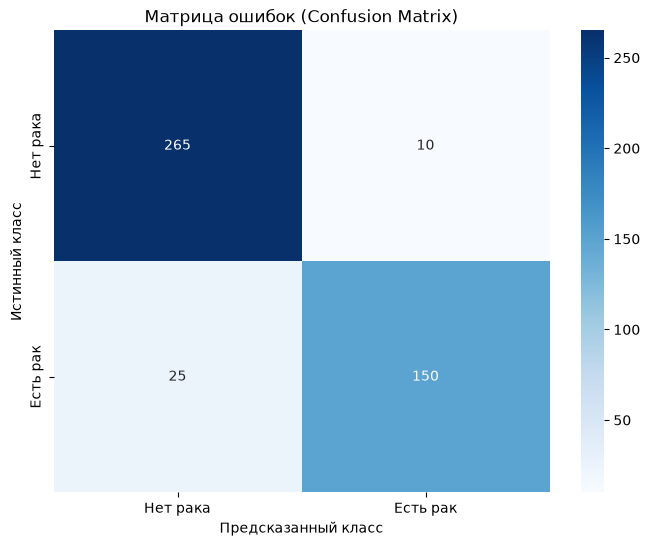

In [29]:
# Строим матрицу ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_rf, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Нет рака", "Есть рак"], yticklabels=["Нет рака", "Есть рак"])
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

### Вывод по оценке Random Forest

Базовый случайный лес получил accuracy **92.22%**. По матрице ошибок модель правильно определила 265 объектов без рака и 150 объектов с раком. Ошибки: 10 ложноположительных и 25 ложноотрицательных прогнозов.

Полнота (recall) класса «Есть рак» составляет **85.71%**: модель обнаружила 150 из 175 объектов с Diagnosis=1. Поэтому для оценки качества необходимо учитывать метрики отдельных классов вместе с общей accuracy.

## 6. Анализ важности признаков

Одна из ключевых особенностей Random Forest — возможность оценить важность каждого признака.

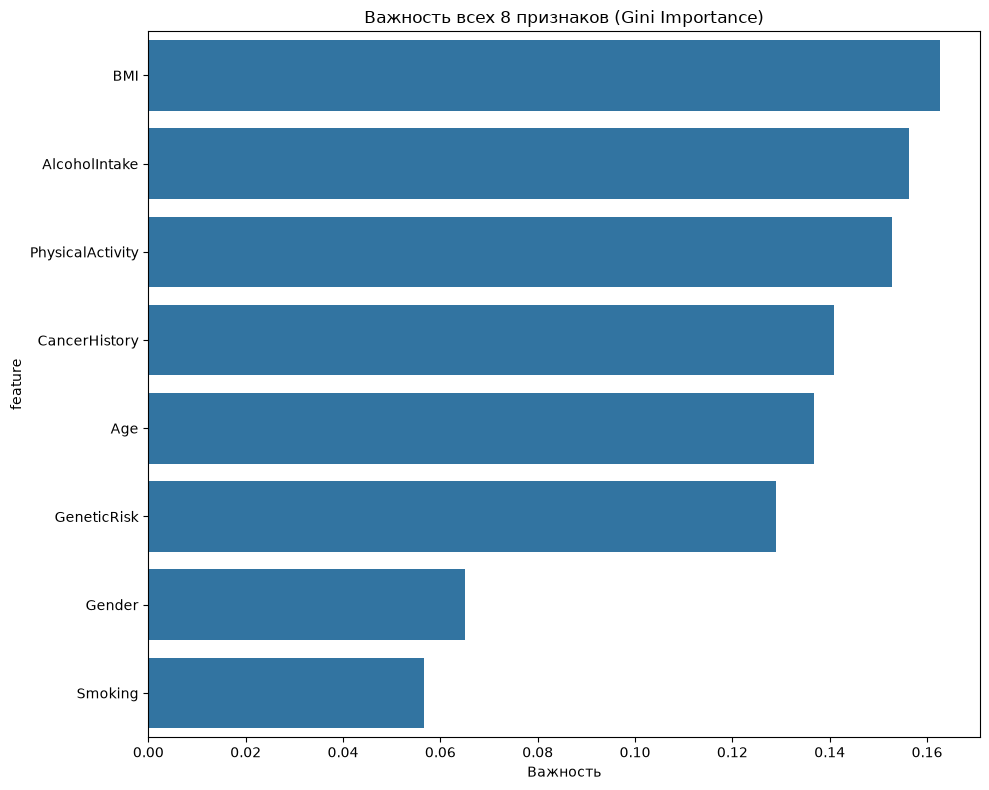

In [30]:
# Важность признаков на основе среднего уменьшения неоднородности (Gini Importance)
feature_importances = rf_model.named_steps["model"].feature_importances_
features_df = pd.DataFrame({'feature': feature_names_rf, 'importance': feature_importances})
features_df = features_df.sort_values('importance', ascending=False)

# Визуализация важности всех признаков
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=features_df)
plt.title(f'Важность всех {len(features_df)} признаков (Gini Importance)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

In [31]:
# Вывод таблицы с важностью всех признаков
print(f"Важность всех {len(features_df)} признаков:")
print(features_df)

Важность всех 8 признаков:
            feature  importance
5               BMI    0.162740
7     AlcoholIntake    0.156210
6  PhysicalActivity    0.152797
3     CancerHistory    0.140976
4               Age    0.136761
2       GeneticRisk    0.128954
0            Gender    0.065015
1           Smoking    0.056548


### Вывод по важности признаков

Наибольшую важность по среднему уменьшению неоднородности в базовом Random Forest получили **BMI, AlcoholIntake, PhysicalActivity**. Эти оценки характеризуют вклад признаков в построение данной модели. Они не устанавливают причинное влияние факторов и могут меняться при другом разбиении данных или других параметрах.

## 7. Подбор гиперпараметров

Подберем гиперпараметры с помощью **GridSearchCV**. Поиск использует только обучающую выборку и выбирает модель по средней accuracy на пяти фолдах. Тестовая выборка используется для оценки результата. Подбор параметров не гарантирует повышения точности на тесте.

In [32]:
# Определяем сетку параметров для перебора
# model__ указывает, что параметр относится к классификатору внутри Pipeline
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [33]:
# Создаем отдельную модель для поиска
rf_for_search = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("model", RandomForestClassifier(random_state=42))
])
grid_search = GridSearchCV(estimator=rf_for_search, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)

# Запускаем поиск (может занять некоторое время)
grid_search.fit(X_train_rf, y_train_rf)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Su

In [34]:
# Выводим лучшие параметры классификатора
best_params = {name.replace("model__", ""): value for name, value in grid_search.best_params_.items()}
print("Лучшие параметры:", best_params)
print("Лучшая точность при кросс-валидации: {:.4f}".format(grid_search.best_score_))

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Лучшая точность при кросс-валидации: 0.9133


In [35]:
# Оцениваем выбранную модель на тестовых данных
best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test_rf)
best_accuracy = accuracy_score(y_test_rf, y_pred_best)
print(f"Точность модели после подбора гиперпараметров на тестовой выборке: {best_accuracy:.4f}")

Точность модели после подбора гиперпараметров на тестовой выборке: 0.9267



Отчет по классификации после подбора гиперпараметров:
              precision    recall  f1-score   support

    Нет рака       0.92      0.97      0.94       275
    Есть рак       0.94      0.86      0.90       175

    accuracy                           0.93       450
   macro avg       0.93      0.92      0.92       450
weighted avg       0.93      0.93      0.93       450



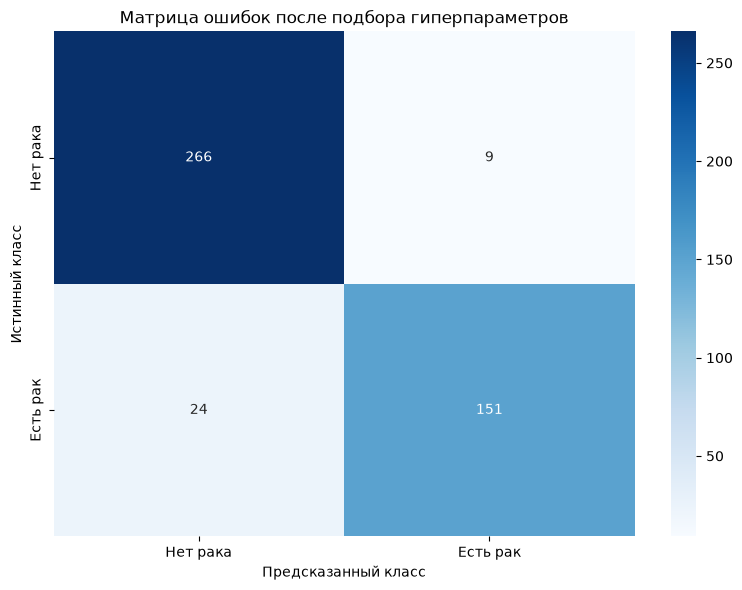

In [36]:
# Подробный отчет для модели после настройки
print("\n" + "="*50)
print("Отчет по классификации после подбора гиперпараметров:")
print("="*50)
print(classification_report(y_test_rf, y_pred_best, target_names=["Нет рака", "Есть рак"]))

# Матрица ошибок модели после настройки
cm_best = confusion_matrix(y_test_rf, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Нет рака", "Есть рак"], yticklabels=["Нет рака", "Есть рак"])
plt.title('Матрица ошибок после подбора гиперпараметров')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

In [37]:
# Сравним модели на одинаковых данных и при одинаковом разбиении CV
baseline_cv_scores = cross_val_score(rf_model, X_train_rf, y_train_rf, cv=5, scoring='accuracy')
rf_comparison = pd.DataFrame({
    'Модель': ['Базовый Random Forest', 'Random Forest после настройки'],
    'Train Accuracy': [accuracy_score(y_train_rf, rf_model.predict(X_train_rf)),
                       accuracy_score(y_train_rf, best_rf_model.predict(X_train_rf))],
    'CV Accuracy': [baseline_cv_scores.mean(), grid_search.best_score_],
    'Test Accuracy': [accuracy, best_accuracy]
}).set_index('Модель')
print(rf_comparison)

                               Train Accuracy  CV Accuracy  Test Accuracy
Модель                                                                   
Базовый Random Forest                1.000000     0.903810       0.922222
Random Forest после настройки        0.978095     0.913333       0.926667


### Вывод по подбору гиперпараметров

Поиск выбрал параметры: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=2.

Средняя accuracy базовой модели при кросс-валидации — **0.9038**, лучшая средняя accuracy в GridSearchCV — **0.9133**. Обе оценки получены на пяти одинаковых фолдах обучающей выборки.

На тесте точность повысилась с 92.22% до 92.67% (на 0.44 процентного пункта). Это результат на данной тестовой выборке. Выбор гиперпараметров выполнялся по тренировочной кросс-валидации, а не по тесту. Лучший результат на фолдах не гарантирует улучшения на отдельной тестовой выборке.

После настройки модель дала 9 ложноположительных и 24 ложноотрицательных прогнозов; recall класса «Есть рак» составляет 86.29%.

## 8. Общий вывод

В работе выполнены загрузка и анализ набора cancer_data.csv, кодирование категориальных признаков и нормализация количественных признаков средствами sklearn. Построены одиночные деревья решений, случайный лес и градиентный бустинг. Качество оценено по accuracy, кросс-валидации, отчетам классификации и матрицам ошибок; изучены важности признаков.

В первой части ограничение глубины дерева до 3 привело к недообучению. Наибольшую тестовую accuracy среди сравниваемых моделей показал Random Forest (95.00%). Во второй части выполнен подбор гиперпараметров случайного леса на обучающей выборке. Итоговая модель получила accuracy 92.67% на тестовой выборке.